In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.patches as patches


def set_figure_defaults():
  plt.rcParams['figure.dpi'] = 300
  plt.rcParams['axes.linewidth'] = 0.5
  plt.rcParams['xtick.major.width'] = 0.5
  plt.rcParams['xtick.minor.width'] = 0.5
  plt.rcParams['ytick.major.width'] = 0.5
  plt.rcParams['ytick.minor.width'] = 0.5
  plt.rcParams['xtick.major.size'] = 2
  plt.rcParams['xtick.minor.size'] = 1.5
  plt.rcParams['ytick.major.size'] = 2
  plt.rcParams['ytick.minor.size'] = 1.5
  plt.rcParams['ytick.labelsize'] = 8
  plt.rcParams['xtick.labelsize'] = 8
  plt.rcParams['font.sans-serif'] = "Arial"
  plt.rcParams['axes.labelsize'] = 8
  plt.rcParams['svg.fonttype'] = 'none'


def render_background(fig, color="#00000010"):
  rect = patches.Rectangle((0, 0), 1, 1, transform=fig.transFigure, color=color, zorder=-1, linewidth=0)
  fig.patches.append(rect)


set_figure_defaults()

%config InlineBackend.figure_format = 'png'
%matplotlib inline  
%load_ext autoreload
%autoreload 2


In [2]:
df = pd.read_hdf(os.path.join(".", "stats", "sweep.h5"))
df.shape

(80886, 9)

In [3]:
df["task"].value_counts()

task
anti             1014
antiseql         1014
antiseqr         1014
ctxdlydm1        1014
ctxdlydm1intl    1014
                 ... 
rtantiseql        702
rtantiseqr        702
rtgo              702
rtgoseql          702
rtgoseqr          702
Name: count, Length: 82, dtype: int64

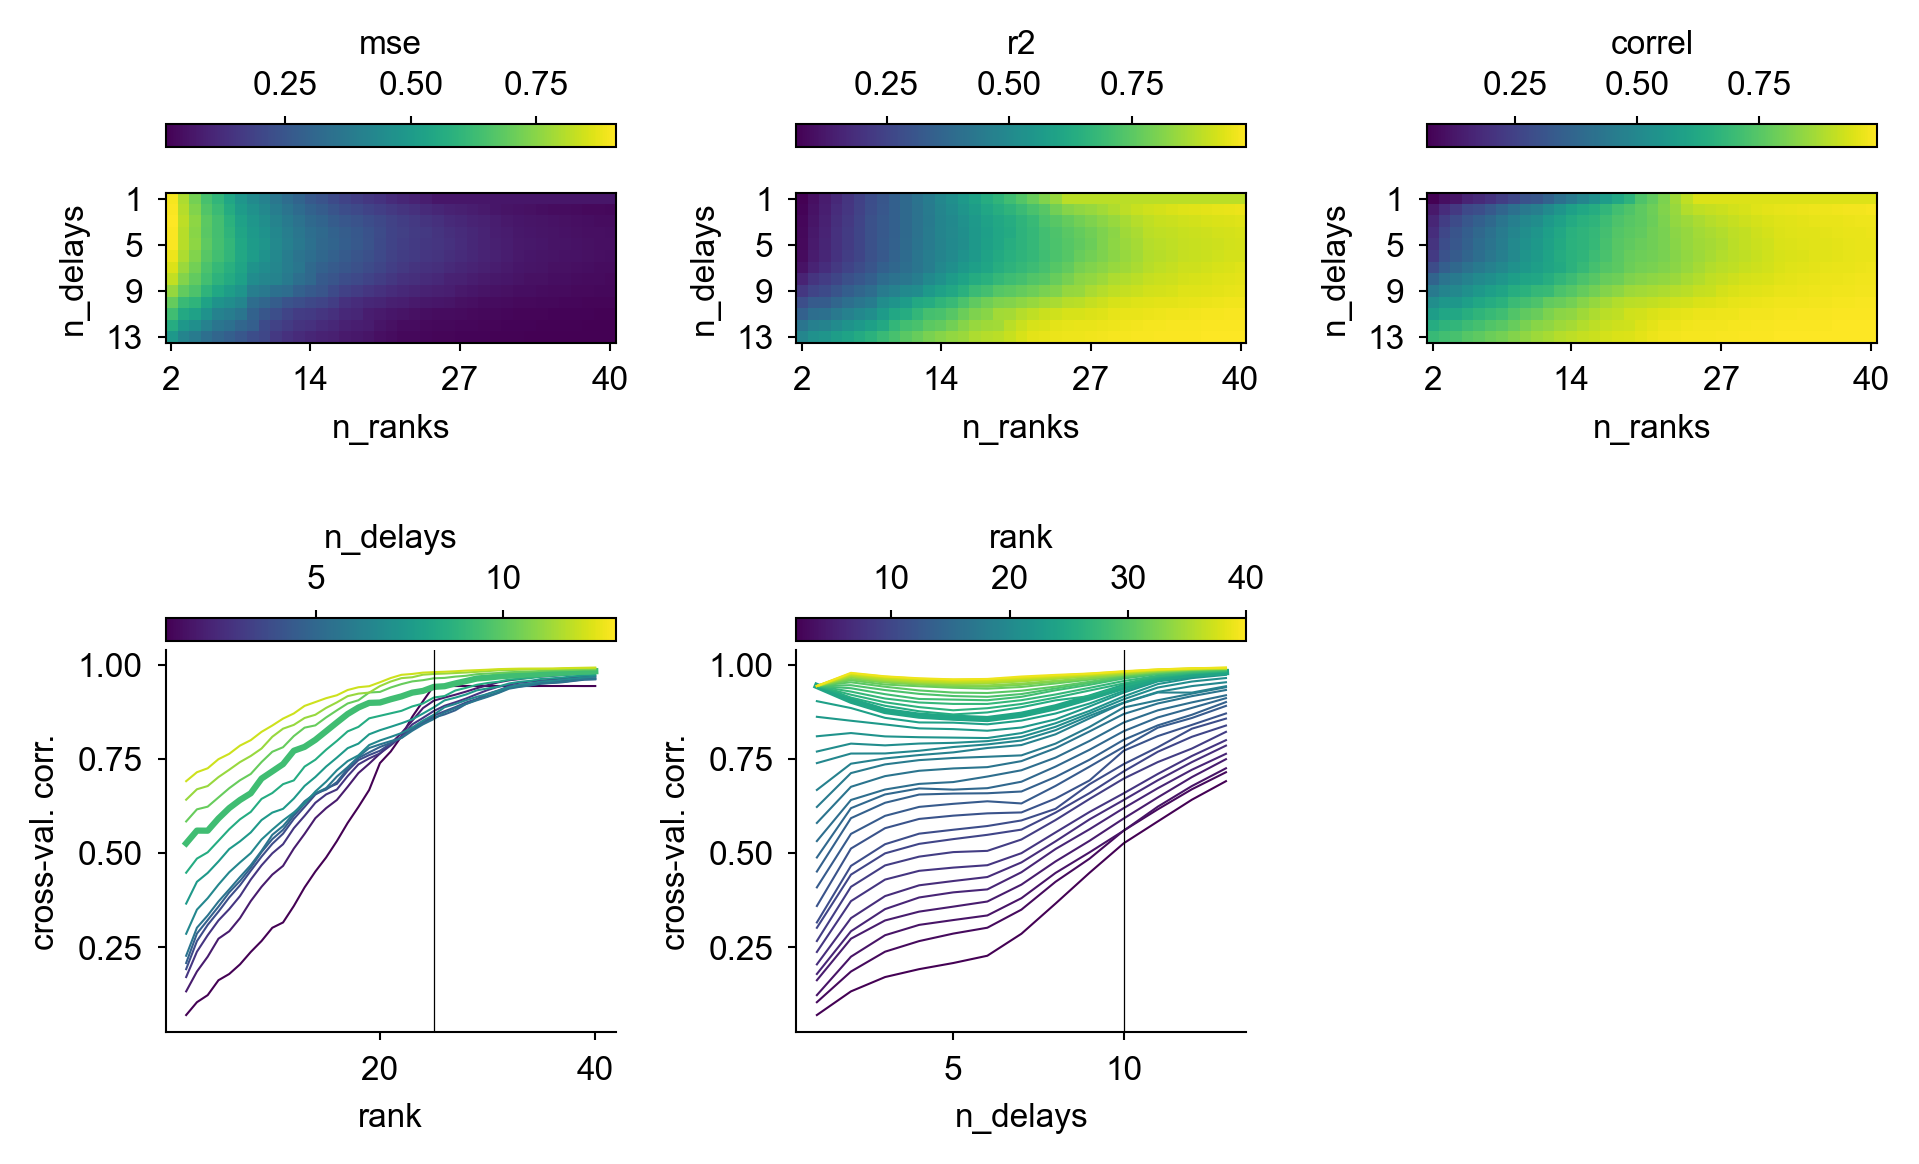

In [4]:

def plot_heatmap(df, x, y, z, axis):
  # Pivot the table: rows = y_param, columns = x_param, values = metric
  heatmap_data = df.pivot_table(index=y, columns=x, values=z)
  im = axis.imshow(heatmap_data, cmap='viridis')

  # x_index = list(heatmap_data.columns)
  # axis.axvline(x_index.index(5), color='k', lw=0.5)
  # axis.axvline(x_index.index(10), color='white', lw=0.5)
  # y_index = list(heatmap_data.index)
  # axis.axhline(y_index.index(40), color='k', lw=0.5)
  # axis.axhline(y_index.index(75), color='white', lw=0.5)

  cbar = plt.colorbar(im, ax=axis, orientation="horizontal", pad=0.1, location="top")
  cbar.set_label(z)
  axis.set_xlabel(x)
  axis.set_ylabel(y)

  xticks = np.linspace(0, heatmap_data.shape[1] - 1, num=4, dtype=int)
  yticks = np.linspace(0, heatmap_data.shape[0] - 1, num=4, dtype=int)
  axis.set_xticks(xticks, heatmap_data.columns[xticks])
  axis.set_yticks(yticks, heatmap_data.index[yticks])


fig, axs = plt.subplots(2, 3, figsize=(6.5, 4), tight_layout=True)

#======================
# heatmaps (panels 1-3)
#======================
df_filt = df[(df["model"] == "gd") & (df["seed"] == 5) & (df["n_components"] == 25) & (df["task"] == "dlyanti")]
plot_heatmap(df_filt, z="mse", x="n_ranks", y="n_delays", axis=axs[0, 0])
plot_heatmap(df_filt, z="r2", x="n_ranks", y="n_delays", axis=axs[0, 1])
plot_heatmap(df_filt, z="correl", x="n_ranks", y="n_delays", axis=axs[0, 2])


selected_delays = [10]
selected_ranks = [25]
#========
# panel 4
#========
viridis = plt.get_cmap('viridis')
for i, n_delays in enumerate(sorted(df_filt["n_delays"].unique())):
    df_rank = df_filt[df_filt["n_delays"] == n_delays]
    x = df_rank.pivot_table(index="n_ranks", values="correl")
    lw = 1.5 if n_delays in selected_delays else 0.5
    axs[1, 0].plot(x.index, x.values, lw=lw, c=viridis(i / len(df_filt["n_delays"].unique())))

for rank in selected_ranks:
  axs[1, 0].axvline(rank, color='k', lw=0.3)

axs[1, 0].set_xlabel("rank")
axs[1, 0].set_ylabel("cross-val. corr.")
axs[1, 0].spines["top"].set_visible(False)
axs[1, 0].spines["right"].set_visible(False)
# Create a normalized colormap for the colorbar
n_delays_vals = sorted(df_filt["n_delays"].unique())
norm = colors.Normalize(vmin=min(n_delays_vals), vmax=max(n_delays_vals))
sm = cm.ScalarMappable(cmap=viridis, norm=norm)
sm.set_array([])  # Dummy array needed for colorbar
cbar = plt.colorbar(sm, ax=axs[1, 0], pad=0.02, location="top")
cbar.set_label("n_delays")


#========
# panel 5
#========
sorted_unique_ranks = sorted(df_filt["n_ranks"].unique())
for counter, rank in enumerate(sorted_unique_ranks):
    df_n_delays = df_filt[df_filt["n_ranks"] == rank]
    x = df_n_delays.pivot_table(index="n_delays", values="correl")
    lw = 1.5 if rank in selected_ranks else 0.5
    c = viridis(counter / len(df_filt["n_ranks"].unique()))
    axs[1, 1].plot(x.index, x.values, lw=lw, c=c)

for delay in selected_delays:
  axs[1, 1].axvline(delay, color='k', lw=0.3)

axs[1, 1].set_xlabel("n_delays")
axs[1, 1].set_ylabel("cross-val. corr.")
axs[1, 1].spines["top"].set_visible(False)
axs[1, 1].spines["right"].set_visible(False)
rank_vals = sorted(df_filt["n_ranks"].unique())
norm = colors.Normalize(vmin=min(rank_vals), vmax=max(rank_vals))
sm = cm.ScalarMappable(cmap=viridis, norm=norm)
sm.set_array([])  # Dummy array needed for colorbar
cbar = plt.colorbar(sm, ax=axs[1, 1], pad=0.02, location="top")
cbar.set_label("rank")

axs[-1, -1].axis("off")


# axs[0, 0].text(0.98, 0.73, "RNN values", transform=axs[0, 0].transAxes, ha='right', va='center', fontsize=8)
# axs[0, 0].text(0.98, 0.37, "neural values", transform=axs[0, 0].transAxes, ha='right', va='center', fontsize=8, color="white")

plt.show()

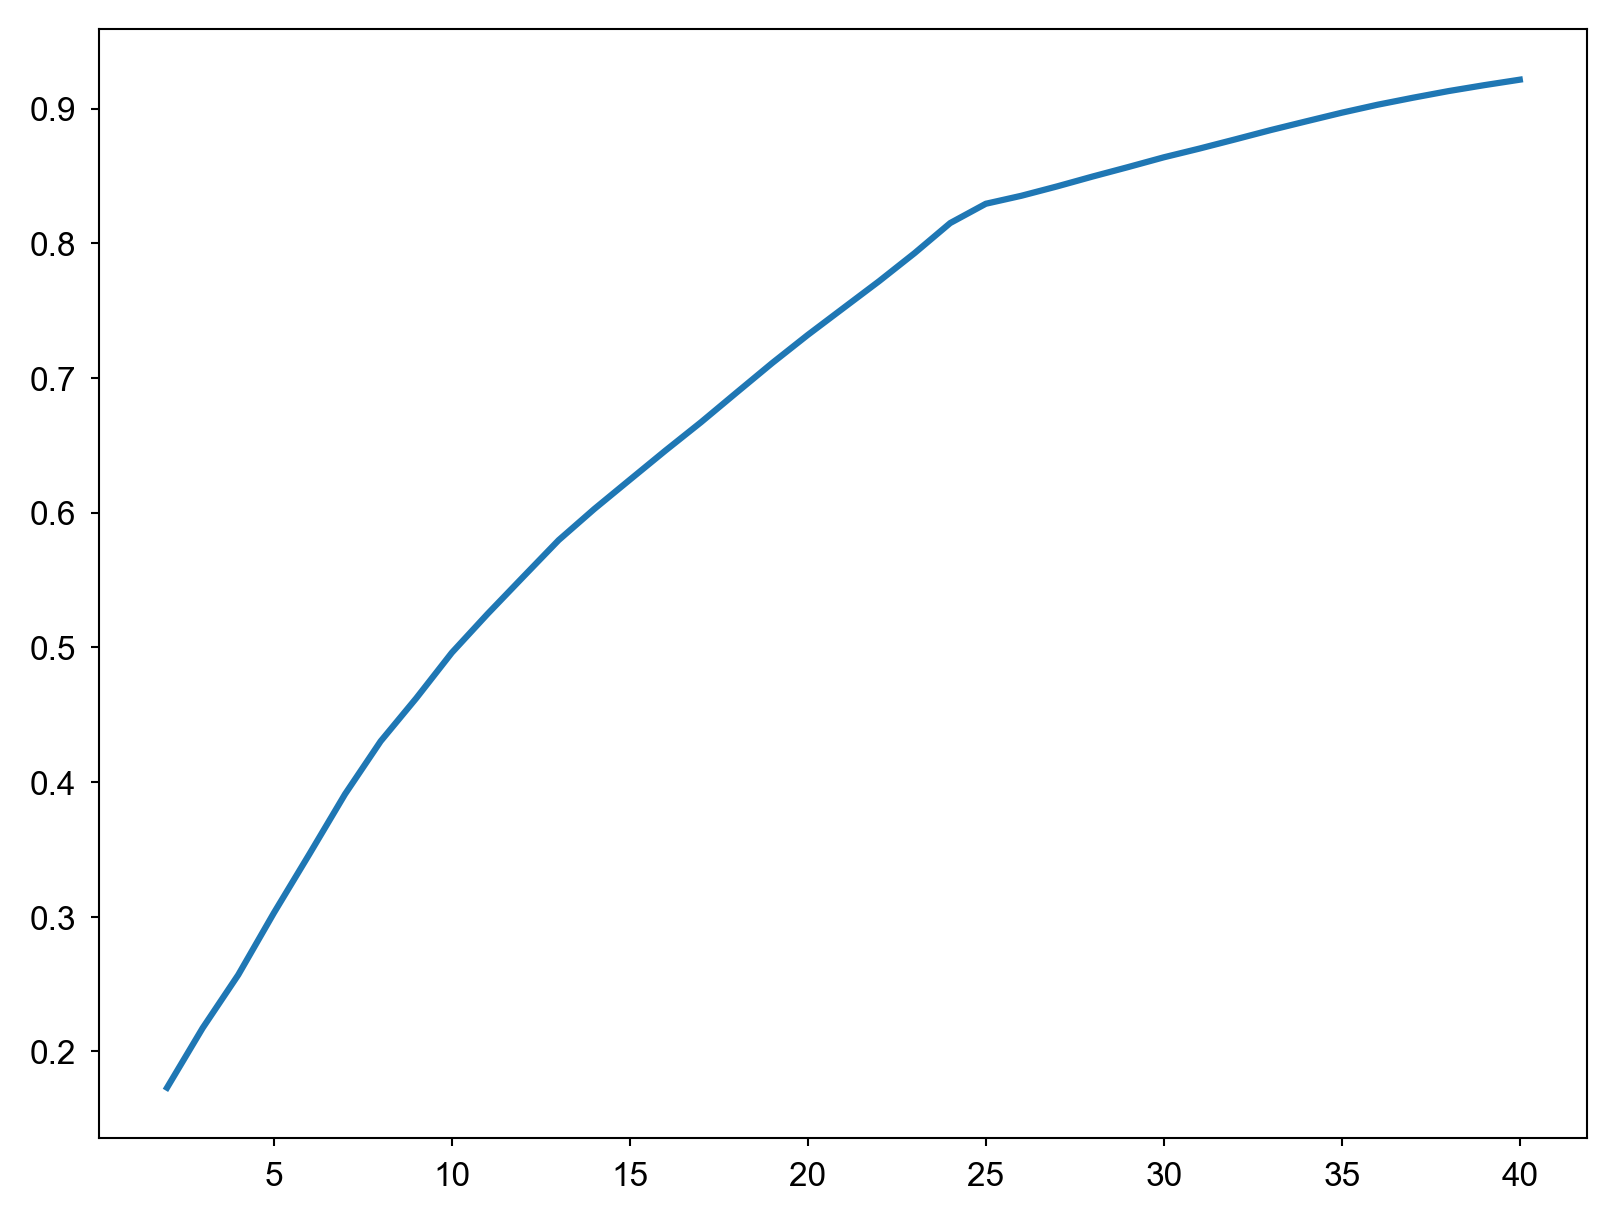

In [5]:
df_filt = df[(df["model"] == "eg") & (df["seed"] == 5) & (df["n_ranks"] == 2) & (df["n_components"] == 25)]
df_filt = df[(df["model"] == "eg") & (df["seed"] == 5) & (df["n_delays"] == 3) & (df["n_components"] == 25)]
x = df_filt.pivot_table(index="n_ranks", values="correl")
plt.plot(x.index, x.values)
